In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy

df = pd.read_csv("houses_simple.csv")
df.head()
df1=df.copy()[['area_sqm','price_k']]
df1.columns=['area','price']


In [3]:
#机器学习
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X = df1[['area']]  # 双括号保持二维结构
y = df1['price']   # 单括号一维即可
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
model=LinearRegression()
model.fit(X_train,y_train)
print("模型训练完成！")
print(f"斜率 (k): {model.coef_[0]}")
print(f"截距 (b): {model.intercept_}")

模型训练完成！
斜率 (k): 3.812063870665771
截距 (b): -29.797370191179994


In [5]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)
print(f"模型 R² 分数: {r2_score(y_test, y_pred)}")

模型 R² 分数: 0.8049192431655599


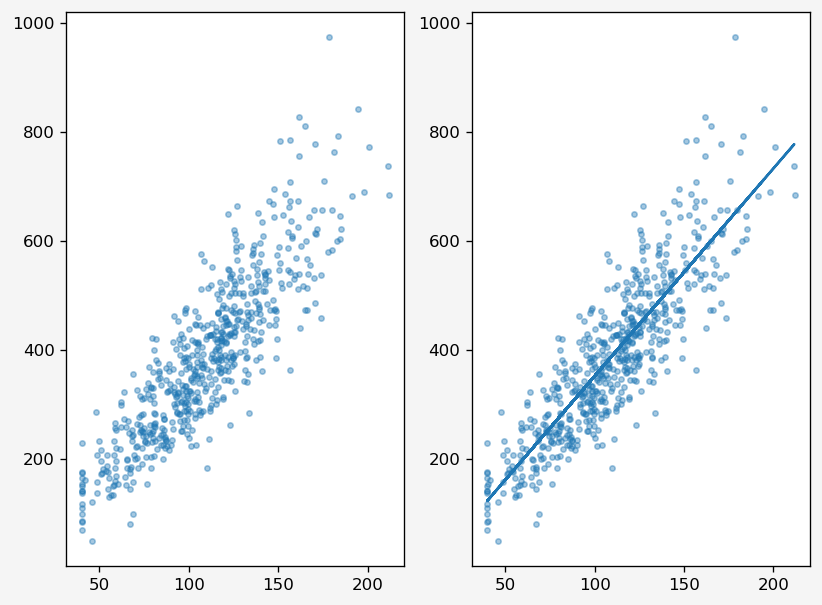

In [8]:
fig,axes=plt.subplots(1,2,figsize=(8,6),dpi=120,facecolor='whitesmoke')
ax1=axes[0]
ax2=axes[1]
ax1.scatter(df1['area'],df1['price'],s=10,alpha=0.4)
ax2.scatter(df1['area'],df1['price'],s=10,alpha=0.4)
ax2.plot(X_test,y_pred)

1.**cost function/loss function**
- it's used to measure the average error over the entire dataset
\begin{flalign*}
J(w,b)  & = \frac{1}{2m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)})-y^{(i)})^2 & \\
        & = \frac{1}{2m}\sum_{i=1}^{m}(w^2(x^{(i)})^2+b^2+2x^{(i)}wb-2x^{(i)}y^{(i)}w-2y^{(i)}b+(y^{(i)})^2) & \\
        & = \frac{1}{2m}\left(w^2\sum_{i=1}^{m}(x^{(i)})^2+mb^2+2wb\sum_{i=1}^{m}x^{(i)}-2w\sum_{i=1}^{m}x^{(i)}y^{(i)}-2b\sum_{i=1}^{m}y^{(i)}+\sum_{i=1}^{m}(y^{(i)})^2\right) &
\end{flalign*}

\begin{flalign*}
H &= \frac{1}{2m}\begin{bmatrix}
  2\sum_{i=1}^{m}(x^{(i)})^2 & 2\sum_{i=1}^{m}x^{(i)} \\
  2\sum_{i=1}^{m}x^{(i)} & 2m
\end{bmatrix} &
\end{flalign*}

\begin{flalign*}
AC - B^2 & = H_{11}H_{22} - H_{12}^2 & \\
         & = \left( \frac{1}{m}\sum_{i=1}^{m}(x^{(i)})^2 \right)(1) - \left( \frac{1}{m}\sum_{i=1}^{m}x^{(i)} \right)^2 & \\
         & = \frac{1}{m}\sum_{i=1}^{m}(x^{(i)})^2 - \left( \frac{1}{m}\sum_{i=1}^{m}x^{(i)} \right)^2 &\\
         & = var(x)>0
\end{flalign*}

\begin{flalign*}
\frac{\partial J}{\partial w} &=\frac{1}{m}\sum_{i=1}^{m}(y\hat{}^{(i)}-y^{(i)})x^{(i)}&\\
\frac{\partial J}{\partial b} &=\frac{1}{m}\sum_{i=1}^{m}(y\hat{}^{(i)}-y^{(i)})&
\end{flalign*}


由此可一判断该函数的形状和极值情况